# 2.1. Clasification multiclass

## Data curation

### Data importation

In [42]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [43]:
def read_data(file_path):
    data = pd.read_csv(file_path, sep=';', decimal=',')
    data['Fecha'] = pd.to_datetime(data['Fecha'], format='%d/%m/%Y %H:%M')
    grid_mapping = {
        '0': 0,
        'A1': 1,
        'A2': 4,
        'A3': 7,
        'B1': 2,
        'B2': 5,
        'B3': 8,
        'C1': 3,
        'C2': 6,
        'C3': 9
    }
    data['Cuadricula'] = data['Cuadricula'].map(grid_mapping)
    return data

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
filepath='2_OMA_600.csv'

In [46]:
data = read_data(filepath)

In [47]:
sensores = 24

#### Migrate to module and phase

In [48]:
def count_fi_columns(df):
  """Counts the number of columns in a DataFrame that follow the format 'fi'.

  Args:
    df: The pandas DataFrame.

  Returns:
    The number of columns matching the pattern.
  """
  pattern = re.compile(r'^f\d+$')  # Regular expression to match 'f' followed by one or more digits
  fi_columns = [col for col in df.columns if pattern.match(col)]
  return len(fi_columns)

In [49]:
# Function to calculate module and phase
def calculate_module_phase(row, i, j):
  """
  Calculates the module and phase for a given row and i, j values.

  Args:
    row: A row of the DataFrame.
    i: The index for the frequency/mode.
    j: The index for the sensor/measurement point.

  Returns:
    A tuple containing the module and phase.
  """
  real_part = row[f'phi_re_{i}_{j}']
  imag_part = row[f'phi_im_{i}_{j}']
  module = np.sqrt(real_part**2 + imag_part**2)
  phase = np.arctan2(imag_part, real_part)
  return module, phase

In [50]:
# Get a list of all phi_re_i_j and phi_im_i_j columns
phi_re_cols = [col for col in data.columns if col.startswith('phi_re_')]
phi_im_cols = [col for col in data.columns if col.startswith('phi_im_')]

# Extract i and j values from column names
ij_values = [(int(col.split('_')[2]), int(col.split('_')[3])) for col in phi_re_cols]

# Create new columns using NumPy for efficiency
modules = np.zeros((len(data), len(phi_re_cols)))
phases = np.zeros((len(data), len(phi_re_cols)))

for idx, (i, j) in enumerate(ij_values):
  real_part = data[f'phi_re_{i}_{j}'].values
  imag_part = data[f'phi_im_{i}_{j}'].values
  modules[:, idx] = np.sqrt(real_part**2 + imag_part**2)
  phases[:, idx] = np.arctan2(imag_part, real_part)

# Create DataFrame for new columns
module_phase_df = pd.DataFrame(
    np.concatenate([modules, phases], axis=1),
    columns=[f'module_{i}_{j}' for i, j in ij_values] +
            [f'phase_{i}_{j}' for i, j in ij_values],
    index=data.index
)

# Concatenate with original DataFrame
data = pd.concat([data, module_phase_df], axis=1)

In [51]:
# Normalize the phase
for i in range(count_fi_columns(data)):  # Assuming 8 frequencies/modes
    # Get the phase column for j=0
    phase_j0_col = f'phase_{i}_0'

    # Loop through the other j values (1 to 23)
    for j in range(sensores):
        # Get the phase column for the current j
        phase_col = f'phase_{i}_{j}'

        # Subtract the phase of j=0 from the current phase
        data[phase_col] = data[phase_col] - data[phase_j0_col]

#### Remove unnecessary data

In [52]:
def drop_columns(df, min, max):

    # Get a list of columns matching the pattern
    columns_to_drop = [f'f{i}' for i in range(7, max)]
    columns_to_drop += [f'x{i}' for i in range(7, max)]
    columns_to_drop += [f'phi_re_{i}_{j}' for i in range(min, max) for j in range(sensores)]
    columns_to_drop += [f'phi_im_{i}_{j}' for i in range(min, max) for j in range(sensores)]
    columns_to_drop += [f'module_{i}_{j}' for i in range(7, max) for j in range(sensores)]
    columns_to_drop += [f'phase_{i}_{j}' for i in range(7, max) for j in range(sensores)]

    # Drop the identified columns
    df = df.drop(columns=columns_to_drop)

    return df

In [53]:
data = drop_columns(data, 0, 11)
data = data.drop(columns=['Peso', 'Fecha'])
data = data[(data != 0).any(axis=1)]
data.reset_index(drop=True, inplace=True)

In [54]:
data.tail()

,Cuadricula,f0,f1,f2,f3,f4,f5,f6,x0,x1,...,phase_6_14,phase_6_15,phase_6_16,phase_6_17,phase_6_18,phase_6_19,phase_6_20,phase_6_21,phase_6_22,phase_6_23
945,9,3.794537,6.119442,8.361846,12.034550,13.049540,14.074826,16.012331,0.011931,0.027926,...,2.518118,2.346296,-0.429281,2.527326,-0.785281,-0.426067,2.533658,-0.759849,-0.386638,2.516653
946,9,3.790707,6.154517,8.456516,9.872427,12.028709,13.040572,14.104690,0.012206,0.024443,...,-1.935258,2.155959,1.670891,-2.652356,-1.427350,1.651308,0.563878,-1.532760,1.688480,-2.118524
947,9,3.788214,6.195023,12.060802,13.037260,14.176409,16.003500,17.538433,0.012021,0.032287,...,2.708121,1.674951,-0.087453,3.080740,-2.498438,-2.672613,2.731461,-2.501546,-2.310663,2.707699
948,9,3.790317,6.104749,8.360450,12.057675,13.024591,14.106662,16.012949,0.010910,0.027368,...,2.530552,-2.376122,1.051065,-2.582325,-0.783434,-0.344910,2.525274,-0.398761,0.131575,2.531885
949,9,3.787989,6.101466,8.370824,12.026626,13.045424,14.075327,16.019136,0.013813,0.027010,...,-0.617625,1.287010,-1.538332,1.357327,2.331056,2.835454,-0.607732,-2.629630,-2.110403,0.543473


### Data splitting

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [56]:
test_size = 0.2
validation_size = 0.25

In [57]:
X = data.drop('Cuadricula', axis=1)  # Features (input columns)
y = data['Cuadricula']  # Labels (target column)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

# Further split train into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=validation_size, random_state=42, stratify=y_train)

### Standarization

In [58]:
# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation and test data using the fitted scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## SVM

In [59]:
from sklearn.svm import SVC
from scipy.stats import uniform, randint
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

### Naive approach

In [60]:
# Create an SVM classifier
svm_model = SVC(kernel='linear')  # You can choose different kernels like 'rbf', 'poly', etc.

# Train the model
svm_model.fit(X_train_scaled, y_train)

SVC(kernel='linear')

In [61]:
# Make predictions on the test set
y_pred_test = svm_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        20
           1       0.95      1.00      0.98        20
           2       0.95      1.00      0.97        19
           3       1.00      0.84      0.91        19
           4       0.94      1.00      0.97        17
           5       0.86      0.95      0.90        19
           6       0.94      0.84      0.89        19
           7       0.95      0.90      0.92        20
           8       1.00      0.95      0.97        19
           9       0.90      1.00      0.95        18

    accuracy                           0.94       190
   macro avg       0.94      0.94      0.94       190
weighted avg       0.94      0.94      0.94       190



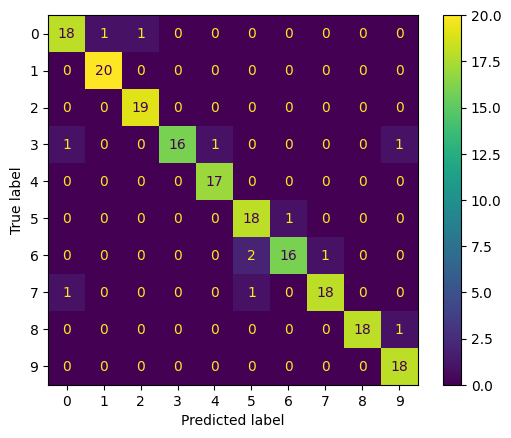

In [62]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot()
plt.show()

### Best model

In [63]:
X_train_val = np.concatenate([X_train_scaled, X_val_scaled])
y_train_val = np.concatenate([y_train, y_val])

In [64]:
param_dist = {
     'kernel': ['linear', 'rbf', 'poly'],
     'C': uniform(0.1, 10),  # Continuous uniform distribution for C
     'gamma': ['scale', 'auto'] + list(uniform(0.1, 1).rvs(size=2)), #scale, auto, and 2 random values from uniform distribution
 }

In [65]:
random_search = RandomizedSearchCV(
     estimator=SVC(),
     param_distributions=param_dist,
     scoring='accuracy',
     cv=10,
     n_iter=10,  # Number of random parameter settings to sample
     random_state=42,  # Set random state for reproducibility
 )

In [66]:
random_search.fit(X_train_val, y_train_val)

RandomizedSearchCV(cv=10, estimator=SVC(),
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7e61e506ab10>,
                                        'gamma': ['scale', 'auto',
                                                  np.float64(0.19143925906773554),
                                                  np.float64(0.7870242633795489)],
                                        'kernel': ['linear', 'rbf', 'poly']},
                   random_state=42, scoring='accuracy')

In [67]:
best_params = random_search.best_params_
best_score = random_search.best_score_
print("Best parameters:", best_params)
print("Best score:", best_score)

Best parameters: {'C': np.float64(7.41993941811405), 'gamma': 'scale', 'kernel': 'linear'}
Best score: 0.9657894736842104


In [68]:
svm_model = random_search.best_estimator_

In [69]:
# Make predictions on the test set
y_pred_test = svm_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.90      0.95      0.93        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        19
           3       0.94      0.89      0.92        19
           4       0.94      1.00      0.97        17
           5       0.90      0.95      0.92        19
           6       0.94      0.89      0.92        19
           7       1.00      1.00      1.00        20
           8       1.00      0.95      0.97        19
           9       0.94      0.94      0.94        18

    accuracy                           0.96       190
   macro avg       0.96      0.96      0.96       190
weighted avg       0.96      0.96      0.96       190



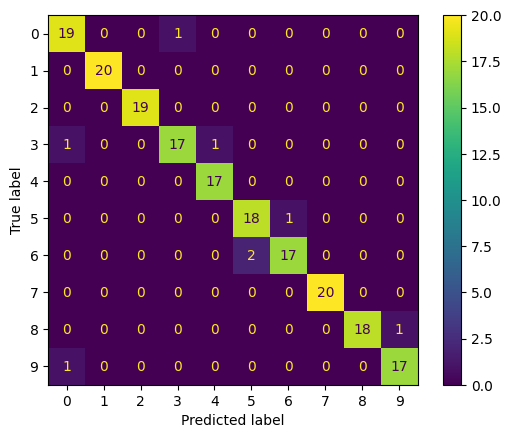

In [70]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot()
plt.show()

## NN

In [71]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import copy
import seaborn as sns

### Data loading

In [72]:
class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)  # Assuming labels are integers

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [73]:
# PARAMETERS
batch_size = 32
num_epochs = 10
learning_rate = 0.001
best_val_loss = float('inf')  # Initialize with a very high value
best_model_state_dict = None

In [74]:
# Create datasets and dataloaders
train_dataset = MyDataset(X_train_scaled, y_train)
val_dataset = MyDataset(X_val_scaled, y_val)
test_dataset = MyDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### Model creation

In [75]:
class MyModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MyModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out

### Training

In [76]:
# Create model, optimizer, and loss function
input_size = X_train.shape[1]  # Number of input features
num_classes = len(y_train.unique())  # Number of output classes

model = MyModel(input_size, num_classes)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()  # Use CrossEntropyLoss for multi-class classification

Epoch [1/10], Train Loss: 2.0362
Epoch [1/10], Validation Loss: 1.7258
Epoch [2/10], Train Loss: 1.3290
Epoch [2/10], Validation Loss: 1.1274
Epoch [3/10], Train Loss: 0.7611
Epoch [3/10], Validation Loss: 0.7943
Epoch [4/10], Train Loss: 0.4084
Epoch [4/10], Validation Loss: 0.5410
Epoch [5/10], Train Loss: 0.2096
Epoch [5/10], Validation Loss: 0.4028
Epoch [6/10], Train Loss: 0.1083
Epoch [6/10], Validation Loss: 0.3371
Epoch [7/10], Train Loss: 0.0620
Epoch [7/10], Validation Loss: 0.2937
Epoch [8/10], Train Loss: 0.0385
Epoch [8/10], Validation Loss: 0.2795
Epoch [9/10], Train Loss: 0.0259
Epoch [9/10], Validation Loss: 0.2583
Epoch [10/10], Train Loss: 0.0177
Epoch [10/10], Validation Loss: 0.2411


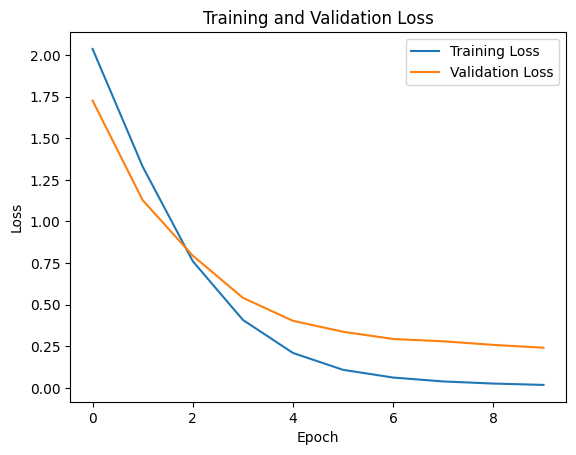

<All keys matched successfully>

In [77]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
  # Training loop
  epoch_train_loss = 0.0  # Accumulate loss for the epoch
  for batch_idx, (data, target) in enumerate(train_loader):
    # Forward pass
    output = model(data)
    loss = criterion(output, target)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_train_loss += loss.item()  # Add batch loss

    # Print progress (optional)
    '''
    if batch_idx % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
    '''
  epoch_train_loss /= len(train_loader)  # Average training loss for the epoch
  train_losses.append(epoch_train_loss)  # Store training loss
  print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}")

  # Validation loop
  model.eval()
  with torch.no_grad():
    val_loss = 0.0
    for data, target in val_loader:
        output = model(data)
        loss = criterion(output, target)
        val_loss += loss.item()

    val_loss /= len(val_loader)  # Average validation loss

    # Check for improvement and save the best model
    if val_loss < best_val_loss: #and epoch_train_loss <= val_loss:
        best_val_loss = val_loss
        best_model_state_dict = copy.deepcopy(model.state_dict())  # Save model state
        torch.save(best_model_state_dict, 'best_model.pth')  # Save to file

  val_losses.append(val_loss)  # Store validation loss
  print(f"Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss:.4f}")

# Plot the losses
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Load the best model state
model.load_state_dict(torch.load('best_model.pth'))

### Evaluation

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        20
           1       0.91      1.00      0.95        20
           2       0.95      0.95      0.95        19
           3       1.00      0.84      0.91        19
           4       0.94      1.00      0.97        17
           5       0.89      0.89      0.89        19
           6       0.89      0.84      0.86        19
           7       0.95      1.00      0.98        20
           8       1.00      0.89      0.94        19
           9       0.85      0.94      0.89        18

    accuracy                           0.93       190
   macro avg       0.93      0.93      0.93       190
weighted avg       0.93      0.93      0.93       190



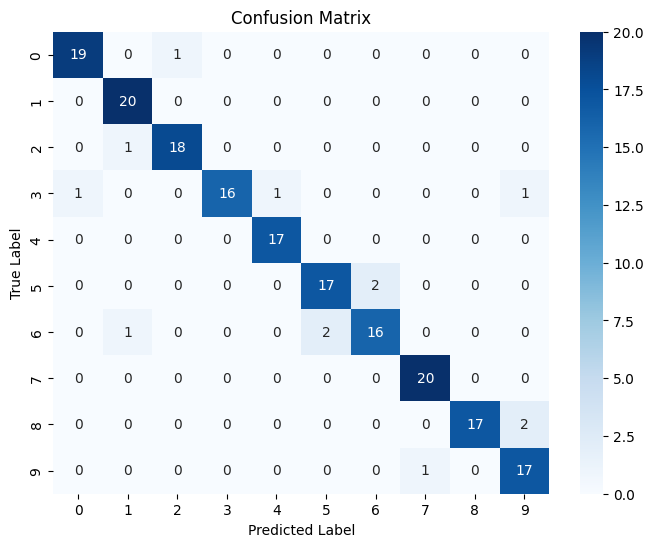

In [78]:
model.eval()

# Make predictions on the test set
y_pred = []
y_true = []

with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        _, predicted = torch.max(output, 1)
        y_pred.extend(predicted.cpu().numpy())  # Convert to NumPy array
        y_true.extend(target.cpu().numpy())  # Convert to NumPy array

# Generate classification report
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(num_classes)]))

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[str(i) for i in range(num_classes)], yticklabels=[str(i) for i in range(num_classes)])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()